In [1]:
# ─────────────────────────────────────────────────────────────
# Day 7 — SFT Training Experiment
# Souvik Kundu · AI PM Master Curriculum
# souvik-ai-pm-portfolio
#
# What this notebook shows:
# Supervised Fine-Tuning (SFT) in action — the same mechanism
# OpenAI used to turn GPT-3 into ChatGPT, at tiny scale.
#
# We train a small transformer on 10 AI PM Q&A pairs and watch
# loss decrease as the model learns the patterns.
# ─────────────────────────────────────────────────────────────

import torch
from torch import nn
from torch.optim import AdamW
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
GPU available: True
Using device: cuda


In [2]:
# ─────────────────────────────────────────────────────────────
# TRAINING DATA — 10 Q&A pairs from Days 1-6
#
# PM explanation: This is the SFT dataset.
# In real SFT (OpenAI training ChatGPT) this is millions of
# human-written pairs. We have 10. Same mechanism, smaller scale.
# ─────────────────────────────────────────────────────────────

training_data = [
    "Q: What is the KV cache? A: It stores K and V vectors from previous tokens to avoid recomputing them on every new token generation.",
    "Q: What is an embedding? A: Tokens are converted to vectors — lists of numbers representing meaning in high-dimensional space. The size of this vector is d_model.",
    "Q: What is attention and how is it calculated? A: For every token three vectors are generated: Q, K and V. Attention is calculated as softmax of Q dot K transposed divided by square root of d, multiplied by V.",
    "Q: What are the differences between transformers and RNN? A: RNN processes tokens sequentially and suffers from vanishing gradients. Transformers process all tokens in parallel with full attention across the entire context.",
    "Q: How is the next token generated? A: Attention provides contextual representation. It flows through feed-forward layers repeated N times, then a final projection produces a probability distribution over vocabulary and the next token is sampled.",
    "Q: What is multi-head attention? A: Single head learns one relationship type. Multi-head runs H parallel attention computations each learning different relationships like coreference, syntax, and semantics.",
    "Q: What is arithmetic intensity? A: Operations performed divided by bytes of memory accessed. High arithmetic intensity means good GPU utilization. Low means the GPU is memory bound and sitting idle.",
    "Q: What is the key inference metric to track? A: Model Bandwidth Utilization. Fifty to seventy percent means well optimized. Below thirty percent signals batching inefficiency or interconnect bottleneck.",
    "Q: What is vLLM? A: vLLM uses PagedAttention — dynamic memory pages for KV cache instead of fixed blocks. Combined with continuous batching it dramatically increases throughput and reduces memory waste.",
    "Q: What happens to throughput when interactivity increases? A: Throughput decreases. Higher interactivity means smaller batches and less parallel GPU utilization.",
]

print(f"Training examples: {len(training_data)}")
print(f"Total characters: {sum(len(t) for t in training_data):,}")
print(f"\nFirst example:")
print(training_data[0])

Training examples: 10
Total characters: 1,943

First example:
Q: What is the KV cache? A: It stores K and V vectors from previous tokens to avoid recomputing them on every new token generation.


In [3]:
# ─────────────────────────────────────────────────────────────
# TOKENIZER — Character level
#
# PM explanation: Real models use subword tokenization (BPE)
# with vocab size ~50,000. We use character-level — every
# unique character is one token. Simpler, less efficient.
# Vocab size = number of unique characters in our data.
# ─────────────────────────────────────────────────────────────

chars = sorted(set(''.join(training_data)))
vocab_size = len(chars)
c2i = {c: i for i, c in enumerate(chars)}
i2c = {i: c for c, i in c2i.items()}

def encode(s):
    return [c2i[c] for c in s]

def decode(ids):
    return ''.join([i2c[i] for i in ids])

print(f"Vocabulary size: {vocab_size} unique characters")
print(f"Characters: {''.join(chars)}")
print(f"\nEncoding test:")
test = "KV cache"
print(f"  '{test}' → {encode(test)}")
print(f"  {encode(test)} → '{decode(encode(test))}'")

Vocabulary size: 54 unique characters
Characters:  ,-.:?ABCFGHIKLMNOPQRSTUVW_abcdefghijklmnopqrstuvwxyz—

Encoding test:
  'KV cache' → [13, 24, 0, 29, 27, 29, 34, 31]
  [13, 24, 0, 29, 27, 29, 34, 31] → 'KV cache'


In [4]:
# ─────────────────────────────────────────────────────────────
# POSITIONAL ENCODING
#
# PM explanation: Transformers process all tokens in parallel
# so they have no built-in sense of order. Positional encoding
# injects a unique signal per position using sine/cosine waves.
# Every position gets a different fingerprint.
# ─────────────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# ─────────────────────────────────────────────────────────────
# TINY TRANSFORMER
#
# PM explanation: Same architecture as GPT-4 — just smaller.
#
#                  Ours      GPT-4
# d_model            64     ~25,600
# n_heads             2          96
# n_layers            2          96
# parameters     73,910   ~1.8 trillion
#
# Same mechanism. 24,000x the scale.
# ─────────────────────────────────────────────────────────────

class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=2, n_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=128,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embed(x)        # integers → vectors
        x = self.pos_enc(x)      # inject position information
        x = self.transformer(x)  # attention + feed-forward
        return self.output(x)    # project to vocabulary scores

model = TinyTransformer(vocab_size).to(device)
total_params = sum(p.numel() for p in model.parameters())

print("Model architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"GPT-4 parameters: ~1,800,000,000,000")
print(f"Scale difference: {1_800_000_000_000 // total_params:,}x")

Model architecture:
TinyTransformer(
  (embed): Embedding(54, 64)
  (pos_enc): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output): Linear(in_features=64, out_features=54, bias=True)
)

Total parameters: 73,910
GPT-4 parameters: ~1,800,000,000,000
Scale difference: 24,353,943x


In [5]:
# ─────────────────────────────────────────────────────────────
# TRAINING LOOP — Gradient descent in action
#
# For each example:
# 1. Feed tokens 1 to N-1 as input
# 2. Ask model to predict tokens 2 to N
# 3. Measure loss — how wrong was the prediction?
# 4. Backpropagate — compute gradients
# 5. Update weights — nudge toward lower loss
# 6. Repeat
#
# This is exactly SFT. OpenAI did this on millions of pairs.
# ─────────────────────────────────────────────────────────────

optimizer = AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 200
loss_history = []

print(f"{'Epoch':>6} | {'Loss':>8} | Signal")
print("-" * 50)

for epoch in range(EPOCHS):
    total_loss = 0
    model.train()

    for text in training_data:
        tokens = torch.tensor(
            encode(text), dtype=torch.long
        ).unsqueeze(0).to(device)

        inputs  = tokens[:, :-1]
        targets = tokens[:, 1:]

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(
            logits.reshape(-1, vocab_size),
            targets.reshape(-1)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(training_data)
    loss_history.append(avg_loss)

    if epoch % 20 == 0:
        if avg_loss > 3.0:
            signal = "random weights — knows nothing"
        elif avg_loss > 2.0:
            signal = "learning character sequences"
        elif avg_loss > 1.0:
            signal = "model getting confident"
        else:
            signal = "well trained on this data"
        print(f"{epoch:>6} | {avg_loss:>8.4f} | {signal}")

print("-" * 50)
print(f"Final loss: {loss_history[-1]:.4f}")
print(f"Improvement: {((loss_history[0]-loss_history[-1])/loss_history[0]*100):.1f}%")

 Epoch |     Loss | Signal
--------------------------------------------------
     0 |   3.6602 | random weights — knows nothing
    20 |   2.0578 | learning character sequences
    40 |   1.5219 | model getting confident
    60 |   1.0913 | model getting confident
    80 |   0.6968 | well trained on this data
   100 |   0.4294 | well trained on this data
   120 |   0.3671 | well trained on this data
   140 |   0.2543 | well trained on this data
   160 |   0.1835 | well trained on this data
   180 |   0.1559 | well trained on this data
--------------------------------------------------
Final loss: 0.1418
Improvement: 96.1%


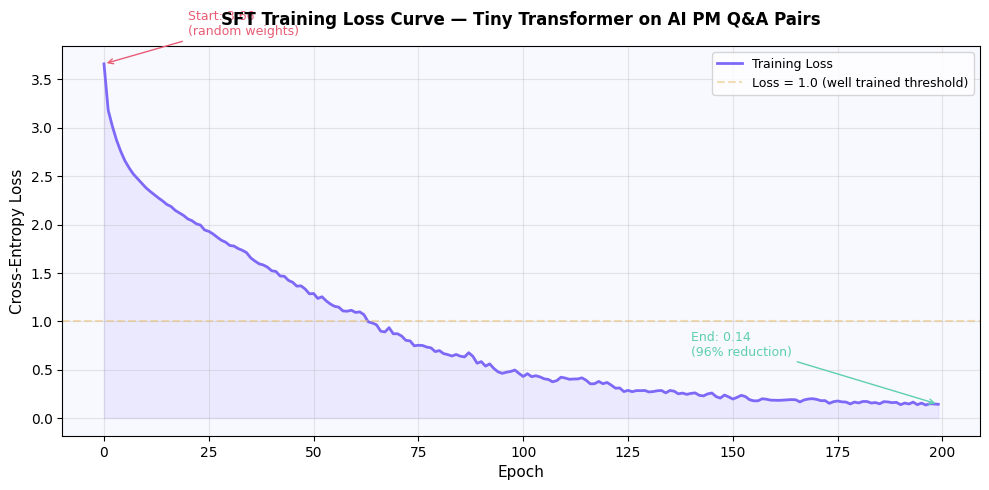

Chart saved as day7_loss_curve.png


In [6]:
# ─────────────────────────────────────────────────────────────
# LOSS CURVE — The heartbeat of training
#
# PM explanation: ML engineers watch this chart the way you
# watched Average Precision in ADC. A smooth curve means
# healthy training. A spike means something went wrong.
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_history, color='#7c6af7', linewidth=2, label='Training Loss')
ax.fill_between(range(len(loss_history)), loss_history,
                alpha=0.1, color='#7c6af7')

# Annotate start and end
ax.annotate(f'Start: {loss_history[0]:.2f}\n(random weights)',
            xy=(0, loss_history[0]),
            xytext=(20, loss_history[0] + 0.3),
            fontsize=9, color='#e85d75',
            arrowprops=dict(arrowstyle='->', color='#e85d75'))

ax.annotate(f'End: {loss_history[-1]:.2f}\n({((loss_history[0]-loss_history[-1])/loss_history[0]*100):.0f}% reduction)',
            xy=(len(loss_history)-1, loss_history[-1]),
            xytext=(len(loss_history)-60, loss_history[-1] + 0.5),
            fontsize=9, color='#5ecfb0',
            arrowprops=dict(arrowstyle='->', color='#5ecfb0'))

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax.set_title('SFT Training Loss Curve — Tiny Transformer on AI PM Q&A Pairs',
             fontsize=12, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f8ff')
fig.patch.set_facecolor('white')

# Add reference lines
ax.axhline(y=1.0, color='#e8c06d', linestyle='--',
           alpha=0.5, label='Loss = 1.0 (well trained threshold)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('day7_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as day7_loss_curve.png")

In [7]:
# ─────────────────────────────────────────────────────────────
# INFERENCE — Switch from training to using the model
#
# PM explanation: Weights are now frozen. We feed a question
# prefix and ask the model to complete it. This is exactly
# what happens when you type into ChatGPT — except our model
# is tiny and only knows 10 Q&A pairs.
# ─────────────────────────────────────────────────────────────

model.eval()

def generate(prompt, max_new_tokens=100, temperature=0.8):
    tokens = torch.tensor(
        encode(prompt), dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(tokens)
            next_logits = logits[:, -1, :] / temperature
            probs = torch.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            tokens = torch.cat([tokens, next_token], dim=1)

    return decode(tokens[0].tolist())

test_prompts = [
    "Q: What is the KV cache? A:",
    "Q: What is vLLM? A:",
    "Q: What is arithmetic intensity? A:",
]

print("INFERENCE TEST")
print("=" * 60)
for prompt in test_prompts:
    result = generate(prompt, max_new_tokens=80)
    completion = result[len(prompt):]
    print(f"\nPrompt:     {prompt}")
    print(f"Completion: {completion[:120]}")
    print("-" * 60)

print("""
NOTE: Output is imperfect because:
1. Only 10 training examples (GPT-4 used millions)
2. Only 73K parameters (GPT-4 has ~1.8 trillion)
3. Character-level tokenization (real models use subword)

The MECHANISM is identical. The scale is not.
""")

INFERENCE TEST

Prompt:     Q: What is the KV cache? A:
Completion:  It s and qucuond V A: proked K p RNNNN thres t tokectiookecanstitind th sufer t
------------------------------------------------------------

Prompt:     Q: What is vLLM? A:
Completion:  c c oon It store K cotont V K K c erond A: Throoke t t toke ife timpemputiomem 
------------------------------------------------------------

Prompt:     Q: What is arithmetic intensity? A:
Completion:  ac K actiprector Feche A: pathrhre t KV. cre acrent memuty th susus everomensma
------------------------------------------------------------

NOTE: Output is imperfect because:
1. Only 10 training examples (GPT-4 used millions)
2. Only 73K parameters (GPT-4 has ~1.8 trillion)
3. Character-level tokenization (real models use subword)

The MECHANISM is identical. The scale is not.



In [8]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           DAY 7 — KEY TAKEAWAYS FOR PM INTERVIEWS           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. SFT is gradient descent on human Q&A pairs.             ║
║     Same mechanism as pre-training. Smaller, better data.   ║
║                                                              ║
║  2. Loss curve is the heartbeat of training.                ║
║     Smooth decrease = healthy. Spike = investigate.         ║
║                                                              ║
║  3. Overfitting = memorizing training data.                 ║
║     Detected via validation loss. Stop before it starts.    ║
║                                                              ║
║  4. More parameters + more data = better model.             ║
║     Relationship governed by Chinchilla scaling laws.       ║
║                                                              ║
║  5. Temperature is a PM decision.                           ║
║     Low = deterministic. High = creative.                   ║
║                                                              ║
║  6. The magic of ChatGPT is not a mysterious algorithm.     ║
║     It is this mechanism at 1,000,000x the scale.           ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           DAY 7 — KEY TAKEAWAYS FOR PM INTERVIEWS           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. SFT is gradient descent on human Q&A pairs.             ║
║     Same mechanism as pre-training. Smaller, better data.   ║
║                                                              ║
║  2. Loss curve is the heartbeat of training.                ║
║     Smooth decrease = healthy. Spike = investigate.         ║
║                                                              ║
║  3. Overfitting = memorizing training data.                 ║
║     Detected via validation loss. Stop before it starts.    ║
║                                                              ║
║  4. More parameters + more data = better model.             ║
║     Relationship governed by Chinchilla scaling laws.       ║
║                                